# Assignment 01

## Rotation Function
### quat_normalize

In [2]:
import numpy as np

def quat_normalize(q: np.ndarray) -> np.ndarray:
    """
    功能：将四元数归一化（使其长度变成1）。
    原理：任何向量/四元数除以它自己的长度，长度就变成了1。
    """
    # np.linalg.norm(q) 会计算 q 这个数组的“几何长度”（即 sqrt(w^2 + x^2 + y^2 + z^2)）
    length = np.linalg.norm(q)
    return q / length

### quat_conjugate - 共轭

#### 1. `np.ndarray` vs `np.array()`

##### `np.ndarray` — 数据类型/类

`np.ndarray` 是 NumPy 的**核心类（class）**，代表 N 维数组对象本身。

```python
import numpy as np

# 创建一个 ndarray 实例
arr = np.array([1, 2, 3])

# 检查类型
print(type(arr))        # <class 'numpy.ndarray'>
print(isinstance(arr, np.ndarray))  # True
```

**关键特性：**
- 它是 NumPy 中所有数组对象的**类型**
- 用于**类型注解**（如你的函数签名所示）
- 表示"这是一个 NumPy 多维数组"

---

##### `np.array()` — 工厂函数

`np.array()` 是一个**函数**，用于**创建** `np.ndarray` 对象。

```python
import numpy as np

# 从列表创建数组
a = np.array([1, 2, 3])           # 一维数组
b = np.array([[1, 2], [3, 4]])    # 二维数组
c = np.array((1, 2, 3))           # 从元组创建
```

**常用参数：**
| 参数 | 说明 |
|------|------|
| `object` | 输入数据（列表、元组等）|
| `dtype` | 指定数据类型（如 `float32`, `int64`）|
| `copy` | 是否强制复制数据 |
| `order` | 内存布局（`'C'`行优先/`'F'`列优先）|
| `ndmin` | 最小维度数 |

```python
# 示例：指定数据类型
arr = np.array([1, 2, 3], dtype=np.float32)
```

---

##### 核心区别总结

| 对比项 | `np.ndarray` | `np.array()` |
|--------|-------------|--------------|
| **本质** | 类（class） | 函数（function） |
| **作用** | 表示数组**类型** | **创建**数组对象 |
| **使用场景** | 类型检查、类型注解 | 实例化数组 |
| **代码位置** | 通常出现在 `->` 后面或 `:` 后面 | 出现在赋值右侧 |

---

#### 2. `->` 箭头符号 — 函数返回类型注解

这是 Python 3.5+ 引入的**类型提示（Type Hints）**语法，用于标注函数的**返回值类型**。

##### 基本语法

```python
def 函数名(参数: 参数类型) -> 返回类型:
    ...
```

> ⚠️ **注意**：Python 的类型注解**不会强制执行**，运行时传入错误类型不会报错。如需检查，需使用 `mypy` 等静态分析工具。

##### 更多示例

```python
from typing import List, Dict, Tuple, Optional

# 基本类型
def add(x: int, y: int) -> int:
    return x + y

# 返回 None
def print_msg(msg: str) -> None:
    print(msg)

# 返回多种可能（Union）
def find_item(items: List[str], target: str) -> Optional[int]:
    # 返回 int 或 None
    try:
        return items.index(target)
    except ValueError:
        return None

# 返回复杂类型
def get_config() -> Dict[str, float]:
    return {"lr": 0.001, "beta": 0.9}

# 返回元组（多个值）
def get_dimensions() -> Tuple[int, int, int]:
    return 1920, 1080, 3  # 宽度、高度、通道数
```

In [3]:
def quat_conjugate(q: np.ndarray) -> np.ndarray:
    """
    Return the conjugate(共轭) of the quaternion.

    Parameters
    ----------
    q: np.ndarray
        Quaternion with shape (4,)

    Returns
    -------
    np.ndarray
        The conjugate of the quaternion with shape (4,)
    """
    return np.array([q[0], -q[1], -q[2], -q[3]])

### quat_multiply

In [4]:
def quat_multiply(q1: np.ndarray, q2: np.ndarray) -> np.ndarray:
    """
    Multiply the two quaternions.

    Parameters
    ----------
    q1, q2: np.ndarray
        Quaternions with shape (4,)

    Returns
    -------
    np.ndarray
        The multiplication result with shape (4,)
    """
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    
    w = w1*w2 - x1*x2 - y1*y2 - z1*z2
    x = w1*x2 + x1*w2 + y1*z2 - z1*y2
    y = w1*y2 - x1*z2 + y1*w2 + z1*x2
    z = w1*z2 + x1*y2 - y1*x2 + z1*w2
    
    return np.array([w, x, y, z])

### quat_relative_angle
#### 1. 数学原理
##### 什么是“相对旋转角度”？

想象你手里拿着一个魔方。
*   魔方现在的姿态是 $q_1$。
*   你想把魔方转到目标姿态 $q_2$。
*   **“相对旋转”** 就是你手腕为了完成这个动作，所施加的那个**“扭动操作”**，我们叫它 $\Delta q$。

在四元数里，连续旋转等于四元数相乘。所以：
$$ 目标姿态 = 相对旋转 \times 当前姿态 $$
$$ q_2 = \Delta q \otimes q_1 $$

既然我们要找的是这个“扭动操作” $\Delta q$，我们在等式两边同时右乘 $q_1$ 的逆（对于单位四元数，逆就是共轭 $q_1^*$）：
$$ \Delta q = q_2 \otimes q_1^* $$

**相对旋转角度的定义，其实就是这个 $\Delta q$ （扭动操作）所对应的那个真实的 3D 旋转角度。**

---

##### 为什么点乘等于 $\cos(\theta/2)$？

任何一个代表旋转的四元数都可以写成：
$$ q =[\cos(\theta/2), \sin(\theta/2)\cdot x, \sin(\theta/2)\cdot y, \sin(\theta/2)\cdot z] $$

现在，我们来看看刚才求出的相对旋转 $\Delta q = q_2 \otimes q_1^*$。
假设 $q_1 =[w_1, x_1, y_1, z_1]$，那么它的共轭 $q_1^* =[w_1, -x_1, -y_1, -z_1]$。
假设 $q_2 =[w_2, x_2, y_2, z_2]$。

我们按照四元数乘法公式，只算 $\Delta q$ 的实部 $w_{\Delta}$（因为我们只需要角度，不需要旋转轴）：
$$ w_{\Delta} = w_2 \cdot w_1 - (x_2 \cdot -x_1) - (y_2 \cdot -y_1) - (z_2 \cdot -z_1) $$
负负得正，化简一下：
$$ w_{\Delta} = w_1 w_2 + x_1 x_2 + y_1 y_2 + z_1 z_2 $$

仔细看上面这个式子，刚好就是把 $q_1$ 和 $q_2$ 当成两个 4 维向量，做**向量点乘（Dot Product）**的公式。
所以：
$$ \Delta q 的实部 = q_1 \cdot q_2 $$
而我们又知道，任何四元数的实部等于 $\cos(\theta/2)$。所以：**两个四元数的点乘，等于 3D 物理旋转角一半的余弦值！**
$$ \text{dot} = q_1 \cdot q_2 = \cos(\frac{\theta_{3D}}{2}) $$

这就是为什么两个四元数的点乘，刚好包含了它们相对角度的信息！这也是为什么
$$ \text{dist}(q_1, q_2) = 2 \arccos(|\langle q_1, q_2 \rangle|) $$
**有个二倍的关系**，因为四元数天生就是用“半角（$\theta/2$）”来编码旋转的。如果你要算真实的 3D 物理空间旋转角度 $\theta$，就必须把 $\arccos$ 算出来的结果乘以 2。

#### 2. `np.clip` 详解

##### 功能

`np.clip` 将数组中的值**裁剪（限制）**在指定的范围内：

```python
np.clip(a, a_min, a_max)
```

- 小于 `a_min` 的值 → 变成 `a_min`
- 大于 `a_max` 的值 → 变成 `a_max`
- 范围内的值 → 保持不变

---

##### 为什么代码里需要它？

```python
d = np.clip(d, -1.0, 1.0)
```

**浮点数精度问题**：

理论上 $|q_1 \cdot q_2| \leq 1$（因为都是单位向量），但由于浮点计算误差：

```python
# 实际情况可能发生：
d = 1.0000000000000002   # 理论上是1，但计算结果略大
# 或
d = -1.0000000000000002  # 理论上是-1，但计算结果略小
```

`np.arccos(x)` 的定义域是 $[-1, 1]$，输入超出会返回 **NaN** 并报警告：

```
RuntimeWarning: invalid value encountered in arccos
```

**`np.clip` 就是保险栓**，确保数值安全落在有效域内。


In [5]:
def quat_relative_angle(q1: np.ndarray, q2: np.ndarray) -> float:
    """
    Compute the relative rotation angle between the two quaternions.

    Parameters
    ----------
    q1, q2: np.ndarray
        Quaternions with shape (4,)

    Returns
    -------
    float
        The relative rotation angle in radians, greater than or equal to 0.
    """
    # 加上 np.abs 是为了保证找到“最短路径”的角度
    d = np.abs(np.dot(q1, q2))
    # np.clip 防止因为计算机浮点数误差导致 d 稍微大于 1 (比如 1.00000001)，导致 arccos 报错
    d = np.clip(d, -1.0, 1.0)
    # 计算角度
    return 2.0 * np.arccos(d)

### interpolate_quat

老师给的公式是：
$$ \text{Slerp}(q_0, q_1, t) = \frac{\sin((1-t)\psi)}{\sin(\psi)} q_0 + \frac{\sin(t\psi)}{\sin(\psi)} q_1 $$
与代码中公式等价，证明如下：

#### 第一步：对齐符号
为了推导方便，我们先把老师公式里的符号和代码里的变量对应起来：
*   老师的 $q_0$ 就是代码里的 $q_1$；
*   老师的 $q_1$ 就是代码里的 $q_2$；
*   老师的 $t$ 就是代码里的 `ratio`（插值比例）；
*   老师的 $\psi$（两个四元数的总夹角）就是代码里的 `theta_0`；
*   我们在代码里定义了当前走过的角度 $\theta = t \cdot \psi$ （代码里的 `theta = theta_0 * ratio`）。

同时别忘了，两个四元数的点乘 `dot`，就等于4D空间中总夹角的余弦值，即：**$\cos(\psi) = \text{dot}$**。

---

#### 第二步：拆解老师的公式

我们重点看 $q_0$ 前面的系数（也就是代码里想求的 `s0`）：
$$ s_0 = \frac{\sin((1-t)\psi)}{\sin(\psi)} $$

把分子乘开：
$$ s_0 = \frac{\sin(\psi - t\psi)}{\sin(\psi)} $$
因为代码里 $t\psi$ 就是 $\theta$，所以：
$$ s_0 = \frac{\sin(\psi - \theta)}{\sin(\psi)} $$

---

#### 第三步：三角函数展开

**两角差的正弦公式**
$$ \sin(A - B) = \sin(A)\cos(B) - \cos(A)\sin(B) $$

我们把这个公式套用到分子 $\sin(\psi - \theta)$ 上：
$$ \sin(\psi - \theta) = \sin(\psi)\cos(\theta) - \cos(\psi)\sin(\theta) $$

现在，把这个展开后的分子放回 $s_0$ 的除法里：
$$ s_0 = \frac{\sin(\psi)\cos(\theta) - \cos(\psi)\sin(\theta)}{\sin(\psi)} $$

把这一项拆成两个分数相减：
$$ s_0 = \frac{\sin(\psi)\cos(\theta)}{\sin(\psi)} - \frac{\cos(\psi)\sin(\theta)}{\sin(\psi)} $$

左边那一项，分子分母都有 $\sin(\psi)$，直接**约分消掉**！
$$ s_0 = \cos(\theta) - \cos(\psi) \frac{\sin(\theta)}{\sin(\psi)} $$

---

#### 第四步：替换成代码里的变量

现在我们把推导出来的最终公式，换回代码里的变量名：
*   $\cos(\theta)$ 就是 `np.cos(theta)`
*   $\cos(\psi)$ 就是点乘结果 `dot`
*   $\sin(\theta)$ 就是 `sin_theta`
*   $\sin(\psi)$ 就是 `sin_theta_0`

带入进去，得到：
$$ s_0 = \text{np.cos(theta)} - \text{dot} \cdot \frac{\text{sin\_theta}}{\text{sin\_theta\_0}} $$

再看 $q_1$ 的系数（即代码里的 `s1`）：
老师的公式里是 $s_1 = \frac{\sin(t\psi)}{\sin(\psi)}$，即 $\frac{\sin(\theta)}{\sin(\psi)}$。
代码里写的正是 `s1 = sin_theta / sin_theta_0`，完全对应。

---

#### 代码公式的优点

**完全可以照抄老师的公式。** 如果你把代码写成下面这样，运行结果也是绝对正确的，而且更容易看懂：
```python
s0 = np.sin((1 - ratio) * theta_0) / np.sin(theta_0)
s1 = np.sin(ratio * theta_0) / np.sin(theta_0)
return s0 * q1 + s1 * q2
```

**那为什么有些经典的工业界代码要用展开后的写法呢？**
1. **减少计算量（微小优化）**：老师的公式需要算两次陌生的正弦值：`sin((1-t)*psi)` 和 `sin(t*psi)`。而在展开版的代码中，底层硬件在计算 `sin(theta)` 的时候，可以利用 CPU 的 `FSINCOS` 指令**同时、极速地**把 `cos(theta)` 也算出来，并且 `dot` 早就已经算好了。这种写法在底层 C/C++ 实现中能压榨出极致的性能。
2. **避免浮点数精度丢失**：在某些极端情况下（比如 ratio 接近 1 时），计算 `1 - ratio` 可能会引入微小的浮点误差。

In [6]:
def interpolate_quat(q1: np.ndarray, q2: np.ndarray, ratio: float) -> np.ndarray:
    """
    Interpolate between two quaternions with given ratio.

    Please use Spherical linear interpolation (SLERP) here.

    When the ratio is 0, return q1; when the ratio is 1, return q2.

    The interpolation should be done in the shortest minor arc connecting the quaternions on the unit sphere.

    If there are multiple correct answers, you can output any of them.

    Parameters
    ----------
    q1, q2: np.ndarray
        Quaternions with shape (4,)
    ratio: float
        The ratio of interpolation, should be in [0, 1]

    Returns
    -------
    np.ndarray
        The interpolated quaternion with shape (4,)

    Note
    ----
    What should be done if the inner product of the quaternions is negative?
    """
    
    dot = np.dot(q1, q2)
    
    # 处理最短路径问题：如果点乘为负，将其中一个四元数反向
    if dot < 0.0:
        q2 = -q2
        dot = -dot
        
    dot = np.clip(dot, -1.0, 1.0)
    
    # 如果两个四元数已经非常接近了，直接用线性插值即可（防止除以0的报错）
    if dot > 0.9995:
        result = q1 + ratio * (q2 - q1)
        return quat_normalize(result)
    
    # SLERP
    theta_0 = np.arccos(dot)        # 总角度
    theta = theta_0 * ratio         # 当前比例对应的角度
    
    # 计算插值
    sin_theta = np.sin(theta)
    sin_theta_0 = np.sin(theta_0)
    
    s0 = np.cos(theta) - dot * sin_theta / sin_theta_0
    s1 = sin_theta / sin_theta_0
    
    return s0 * q1 + s1 * q2

### quat_to_mat

#### 旋转矩阵的本质是什么？

在开始推导之前，我们必须先弄懂：**一个 $3 \times 3$ 的旋转矩阵 $R$ 到底长什么样？**

在线性代数中，旋转矩阵 $R$ 的**每一列**，其实就是原来的基底向量（X轴、Y轴、Z轴）经过旋转之后，在空间中对应的**新坐标**。

$$ R = \begin{bmatrix} | & | & | \\ \vec{X}_{new} & \vec{Y}_{new} & \vec{Z}_{new} \\ | & | & | \end{bmatrix} $$
也就是说：
*   矩阵的**第一列**，是纯粹的 $X$ 轴向量 $(1, 0, 0)$ 旋转后的结果。
*   矩阵的**第二列**，是纯粹的 $Y$ 轴向量 $(0, 1, 0)$ 旋转后的结果。
*   矩阵的**第三列**，是纯粹的 $Z$ 轴向量 $(0, 0, 1)$ 旋转后的结果。

记住了这个核心概念，我们就可以开始用四元数来“徒手捏”出一个旋转矩阵了！

我们在之前讲过，用四元数 $q = [w, x, y, z]$ 去旋转一个三维向量 $\vec{v}$，公式是：
$$ \vec{v}_{new} = q \otimes \vec{v}_{q} \otimes q^* $$
（其中 $\vec{v}_{q} =[0, v_x, v_y, v_z]$， $q^* =[w, -x, -y, -z]$）

既然旋转矩阵的第一列是 $X$ 轴向量 $(1, 0, 0)$ 旋转后的结果，那我们干脆就**把 $X$ 轴代入四元数的旋转公式算一遍**！

让 $\vec{v} = (1, 0, 0)$，补成纯四元数 $\vec{v}_q = [0, 1, 0, 0]$。
我们需要计算： $[w, x, y, z] \otimes[0, 1, 0, 0] \otimes [w, -x, -y, -z]$。

**第一步：先算前两个相乘 $q \otimes \vec{v}_q$**
套用我们第一节课写的哈密顿乘积公式（纯代数展开）：
*   $w_{tmp} = w(0) - x(1) - y(0) - z(0) = -x$
*   $x_{tmp} = w(1) + x(0) + y(0) - z(0) = w$
*   $y_{tmp} = w(0) - x(0) + y(0) + z(1) = z$
*   $z_{tmp} = w(0) + x(0) - y(1) + z(0) = -y$
结果是中间四元数：$[-x, w, z, -y]$

**第二步：再乘以共轭 $q^*$**
也就是计算：$[-x, w, z, -y] \otimes [w, -x, -y, -z]$。继续套乘法公式：
*   **实部 $w_{new}$**: $(-x)(w) - (w)(-x) - (z)(-y) - (-y)(-z) = -xw + xw + zy - yz = 0$。（完美！实部为0，说明结果确实是一个纯三维向量！）
*   **虚部 $x_{new}$**: $(-x)(-x) + (w)(w) + (z)(-z) - (-y)(-y) = x^2 + w^2 - z^2 - y^2$
*   **虚部 $y_{new}$**: $(-x)(-y) - (w)(-z) + (z)(w) + (-y)(-x) = xy + wz + zw + xy = 2xy + 2wz$
*   **虚部 $z_{new}$**: $(-x)(-z) + (w)(-y) - (z)(-x) + (-y)(w) = xz - wy + zx - yw = 2xz - 2wy$

**第三步：化简 $x_{new}$**
别忘了，我们的四元数是**单位四元数**，满足 $w^2 + x^2 + y^2 + z^2 = 1$。
所以 $w^2 + x^2 = 1 - y^2 - z^2$。
把这个代入刚才求出的 $x_{new}$ 中：
$$ x_{new} = (w^2 + x^2) - y^2 - z^2 = (1 - y^2 - z^2) - y^2 - z^2 = 1 - 2y^2 - 2z^2 $$

**看！奇迹出现了！**
经过旋转后，原本的 $X$ 轴向量变成了：
$$ \begin{bmatrix} 1 - 2y^2 - 2z^2 \\ 2xy + 2wz \\ 2xz - 2wy \end{bmatrix} $$
你对比一下你代码里的 `quat_to_mat`，**这完完全全就是旋转矩阵的第一列！**

同理：
把 $Y$ 轴 $[0, 0, 1, 0]$ 代入算一遍，得到矩阵**第二列**。
把 $Z$ 轴 $[0, 0, 0, 1]$ 代入算一遍，得到矩阵**第三列**。

将这三列拼起来，就是完整的 $3 \times 3$ 旋转矩阵公式：
$$ R = \begin{bmatrix} 1 - 2y^2 - 2z^2 & 2xy - 2wz & 2xz + 2wy \\ 2xy + 2wz & 1 - 2x^2 - 2z^2 & 2yz - 2wx \\ 2xz - 2wy & 2yz + 2wx & 1 - 2x^2 - 2y^2 \end{bmatrix} $$
这就是代码中 `quat_to_mat` 的绝对严谨的推导来源！

---


### mat_to_quat

现在，我们反过来。已知上面的那个大矩阵 $R$，里面装满了数字（比如我们叫它 $R_{00}$ 到 $R_{22}$），我们怎么反向解出 $w, x, y, z$？

这就像是在解一个非线性方程组。

#### 第一招：利用“迹（Trace）”求出 $w$
矩阵的“迹”（主对角线元素之和）在旋转中是一个非常有用的不变量。
把上面矩阵对角线上的三个元素加起来：
$$ \text{Trace}(R) = R_{00} + R_{11} + R_{22} $$
$$ = (1 - 2y^2 - 2z^2) + (1 - 2x^2 - 2z^2) + (1 - 2x^2 - 2y^2) $$
$$ = 3 - 4x^2 - 4y^2 - 4z^2 $$
提取公因式 $4$：
$$ = 3 - 4(x^2 + y^2 + z^2) $$

还是利用单位四元数性质：$x^2 + y^2 + z^2 = 1 - w^2$。代入进去：
$$ \text{Trace}(R) = 3 - 4(1 - w^2) = 3 - 4 + 4w^2 = 4w^2 - 1 $$

移项解出 $w$：
$$ 4w^2 = \text{Trace}(R) + 1 $$
$$ w = \frac{\sqrt{\text{Trace}(R) + 1}}{2} $$
这就对应了代码里：`S = np.sqrt(tr + 1.0) * 2; w = 0.25 * S` （这里 `S` 其实就是 $4w$）。

#### 第二招：利用“反对角线之差”求出 $x, y, z$
已知了 $w$（也就是知道了代码里的 `S`），我们来看矩阵反对称位置上的元素之差：

观察矩阵：
$$ R_{21} - R_{12} = (2yz + 2wx) - (2yz - 2wx) = 4wx $$
所以： $x = \frac{R_{21} - R_{12}}{4w}$

$$ R_{02} - R_{20} = (2xz + 2wy) - (2xz - 2wy) = 4wy $$
所以： $y = \frac{R_{02} - R_{20}}{4w}$

$$ R_{10} - R_{01} = (2xy + 2wz) - (2xy - 2wz) = 4wz $$
所以： $z = \frac{R_{10} - R_{01}}{4w}$

**到这里，正常的矩阵转四元数就推导完了！这就是代码里第一个 `if tr > 0:` 分支的原理。**

---
#### 拆解 `mat_to_quat` 中的三个 `elif`

我们已经推导出了怎么用“迹（Trace）”求出 $w$，再用 $w$ 当分母求出 $x, y, z$。
$$ w = \frac{\sqrt{\text{Trace} + 1}}{2} $$
$$ x = \frac{R_{21} - R_{12}}{4w}, \quad y = \frac{R_{02} - R_{20}}{4w}, \quad z = \frac{R_{10} - R_{01}}{4w} $$

但是，**为什么非要写那么长的一堆 `elif` 呢？**

1. “除以零”与数值不稳定
   
假设机器人转到了一个特殊的姿态（比如刚好转了 180度）。这个时候，算出来的 $w$ 是 $0$ 或者极其接近 $0$（比如 `0.0000000001`）。
*   如果在数学上 $w=0$，代码一运行到 $x = \frac{R_{21} - R_{12}}{4w}$，直接**除以 0 报错崩溃**。
*   如果在工程上 $w$ 极小，虽然没报错，但浮点数相除会把微小的误差放大几千万倍，算出来的四元数直接飞出银河系，这就是所谓的**“数值不稳定”**。

1. Shoemake 的解法：谁大，我就先求谁
   
为了保证除法绝对安全，前人发明了一个极其聪明的策略：
**在 $w, x, y, z$ 这四个人里，我先看谁的绝对值最大。我把最大的那个求出来当分母，这样分母最大，除法就最安全、最精准！**

我们来看看怎么不用求开方，光看矩阵 $R$ 的元素，就能判断出这四个人谁最大：
（回忆四元数转矩阵的对角线公式）
*   $R_{00} = 1 - 2y^2 - 2z^2 = w^2 + x^2 - y^2 - z^2$
*   $R_{11} = 1 - 2x^2 - 2z^2 = w^2 - x^2 + y^2 - z^2$
*   $R_{22} = 1 - 2x^2 - 2y^2 = w^2 - x^2 - y^2 + z^2$
*   $\text{Trace} = R_{00} + R_{11} + R_{22} = 4w^2 - 1$

你可以通过简单的数学组合，推导出下面这四个“平方级”的公式：
1.  **$4w^2 = 1 + \text{Trace}$**
2.  **$4x^2 = 1 + R_{00} - R_{11} - R_{22}$**
3.  **$4y^2 = 1 - R_{00} + R_{11} - R_{22}$**
4.  **$4z^2 = 1 - R_{00} - R_{11} + R_{22}$**

仔细观察上面这四个式子，你会发现一个规律：**矩阵的对角线元素（$R_{00}, R_{11}, R_{22}$）谁大，对应的轴（$x, y, z$）的值就大！**

3. 逐行翻译 `if-elif` 逻辑树

现在我们来看代码里是怎么挑出那个“最大值”的：

*   **`if tr > 0:`**
    这说明 $4w^2 = 1 + \text{Trace} > 1$。所以 $w > 0.5$。因为四个数的平方和等于1，既然 $w$ 的平方已经占了老大一块，那 **$w$ 绝对是最大的！** 所以我们心安理得地先求 $w$，然后用 $w$ 当分母去求 $x, y, z$。

*   **`elif (m00 > m11) and (m00 > m22):`**
    （现在 $w$ 肯定不是最大的了，我们在 $x, y, z$ 里挑高个儿）
    如果 $R_{00}$（即代码里的 `m00`）是对角线里最大的。你看上面 $4x^2$ 的公式，它是 $+R_{00}$，减去另外两个。所以此时 **$x$ 是最大的！**
    既然 $x$ 最大，我们就先求 $x$：
    $$ x = \frac{\sqrt{1 + R_{00} - R_{11} - R_{22}}}{2} $$
    代码里提取出了 $4x$ 也就是 `S = np.sqrt(1.0 + m00 - m11 - m22) * 2`。
    然后再利用矩阵的对称和反对称性质，推导出用 $S$（即 $4x$）做分母去求 $w, y, z$ 的公式。

*   **`elif m11 > m22:`**
    能走到这里，说明 $R_{00}$ 不是最大的，那就剩下 $R_{11}$ 和 $R_{22}$ PK了。
    如果 $R_{11} > R_{22}$，说明 **$y$ 是最大的！**
    我们同理先求 $y$，用 $y$ 当分母求 $w, x, z$。

*   **`else:`**
    只剩一种情况了：**$z$ 是最大的！**
    先求 $z$，用 $z$ 当分母求 $w, x, y$。

4. 总结
   
这长长的一坨 `if-elif-else`，本质上**完全不是为了实现新的数学功能，纯粹是为了“算法的鲁棒性（Robustness）”**。

In [7]:
def mat_to_quat(mat: np.ndarray) -> np.ndarray:
    """
    Convert the rotation matrix to quaternion.

    Parameters
    ----------
    mat: np.ndarray
        The rotation matrix with shape (3, 3)

    Returns
    -------
    np.ndarray
        The quaternion with shape (4,)
    """
    # 提取矩阵的 9 个元素
    m00, m01, m02 = mat[0, 0], mat[0, 1], mat[0, 2]
    m10, m11, m12 = mat[1, 0], mat[1, 1], mat[1, 2]
    m20, m21, m22 = mat[2, 0], mat[2, 1], mat[2, 2]
    
    tr = m00 + m11 + m22 # 迹

    # 根据图形学的经典算法，分成 4 种情况处理，防止除以 0
    if tr > 0:
        S = np.sqrt(tr + 1.0) * 2
        w = 0.25 * S
        x = (m21 - m12) / S
        y = (m02 - m20) / S
        z = (m10 - m01) / S
    elif (m00 > m11) and (m00 > m22):
        S = np.sqrt(1.0 + m00 - m11 - m22) * 2
        w = (m21 - m12) / S
        x = 0.25 * S
        y = (m01 + m10) / S
        z = (m02 + m20) / S
    elif m11 > m22:
        S = np.sqrt(1.0 + m11 - m00 - m22) * 2
        w = (m02 - m20) / S
        x = (m01 + m10) / S
        y = 0.25 * S
        z = (m12 + m21) / S
    else:
        S = np.sqrt(1.0 + m22 - m00 - m11) * 2
        w = (m10 - m01) / S
        x = (m02 + m20) / S
        y = (m12 + m21) / S
        z = 0.25 * S
        
    return quat_normalize(np.array([w, x, y, z]))

### quat_to_axis_angle
> `The length of the axis-angle vector should be less or equal to pi.`
> （轴角向量的长度（也就是旋转角度）必须**小于等于 $\pi$**，即 180度）。

四元数 $q$ 和 $-q$ 代表的是同一个 3D 姿态。
*   如果你用 $q$，算出来的可能是：**“顺时针转 270 度”**。
*   如果你用 $-q$，算出来的就是：**“逆时针转 90 度”**。

报错传入的那个四元数 $q$，它的实部 $w = -0.7756$。
因为 $w = \cos(\theta / 2)$，如果 $w$ 是负数，说明 $\theta / 2 > 90^\circ$，也就是**总旋转角度 $\theta > 180^\circ (\pi)$**，走了那条“绕远路”的劣弧。

修改：既然 $w < 0$ 意味着角度大于 180 度，我们只需要**在计算前，判断一下 $w$ 是不是小于 0。如果是，就把整个四元数取反（$-q$）**，这样就能保证算出来的角度永远 $\le 180^\circ$ 了

In [ ]:
def quat_to_axis_angle(q: np.ndarray) -> np.ndarray:
    """
    Convert the quaternion to axis-angle representation.

    The length of the axis-angle vector should be less or equal to pi.

    If there are multiple answers, you can output any.

    Parameters
    ----------
    q: np.ndarray
        The quaternion with shape (4,)

    Returns
    -------
    np.ndarray
        The axis-angle representation with shape (3,)
    """
    # 如果 w < 0，说明旋转角度大于 180度（pi），取相反的四元数来走最短路径
    if q[0] < 0:
        q = -q

    w = np.clip(q[0], -1.0, 1.0)
    theta = 2.0 * np.arccos(w) # 提取旋转角度
    
    # 如果角度是 0（或者非常接近0），说明没有旋转
    if theta < 1e-6:
        return np.array([0.0, 0.0, 0.0])
    
    # 提取旋转轴 (虚部) 并归一化
    axis = q[1:] / np.linalg.norm(q[1:])
    
    # 返回 轴方向 * 角度
    return axis * theta

### axis_angle_to_quat
#### 旋转向量（Axis-Angle → Vector）

旋转可以用两个要素描述：
- **旋转轴** $\hat{\omega}$：单位向量，表示绕哪个轴转
- **旋转角** $\theta$：标量，表示转多少

**旋转向量**将这两者合并为一个向量：
$$\mathbf{r} = \theta \cdot \hat{\omega}$$

| 属性 | 含义 |
|------|------|
| **方向** | 旋转轴的方向 |
| **长度（模）** | 旋转角度的大小（弧度）|

$$\mathbf{r} = \begin{bmatrix} r_x \\ r_y \\ r_z \end{bmatrix} = \theta \cdot \begin{bmatrix} \omega_x \\ \omega_y \\ \omega_z \end{bmatrix}$$

In [8]:
def axis_angle_to_quat(aa: np.ndarray) -> np.ndarray:
    """
    Convert the axis-angle representation to quaternion.

    The length of the axis-angle vector should be less or equal to pi

    Parameters
    ----------
    aa: np.ndarray
        The axis-angle representation with shape (3,)

    Returns
    -------
    np.ndarray
        The quaternion with shape (4,)
    """
    theta = np.linalg.norm(aa)
    
    # 如果没有旋转，返回单位四元数 [1, 0, 0, 0]
    if theta < 1e-6:
        return np.array([1.0, 0.0, 0.0, 0.0])
    
    axis = aa / theta # 获取单位长度的旋转轴
    
    w = np.cos(theta / 2.0)
    xyz = axis * np.sin(theta / 2.0)
    
    return np.array([w, xyz[0], xyz[1], xyz[2]])

## FK

### 1. 关于 `isinstance` 的功能

`isinstance` 不是用来判断“两个变量”是否相同，而是判断 **“一个对象（变量）”是否是“某个类（或其子类）的实例”**。

*   **语法：** `isinstance(对象，类)`
*   **含义：** 这个对象是不是由这个类（或它的子类）创建出来的？
*   **例子：**
    ```python
    class Joint: pass
    class RevoluteJoint(Joint): pass # 旋转关节继承自通用关节

    j1 = RevoluteJoint()
    j2 = Joint()

    isinstance(j1, RevoluteJoint) # True (j1 就是旋转关节)
    isinstance(j1, Joint)         # True (因为继承关系，旋转关节也是关节)
    isinstance(j2, RevoluteJoint) # False (j2 只是普通关节，不是旋转的)
    ```

所以，代码 `isinstance(joint, RevoluteJoint)` 的意思是：**“变量 `joint` 所指向的这个对象，它的类型是不是 `RevoluteJoint`（或者它的子类）？”**

### 2. enumerate()
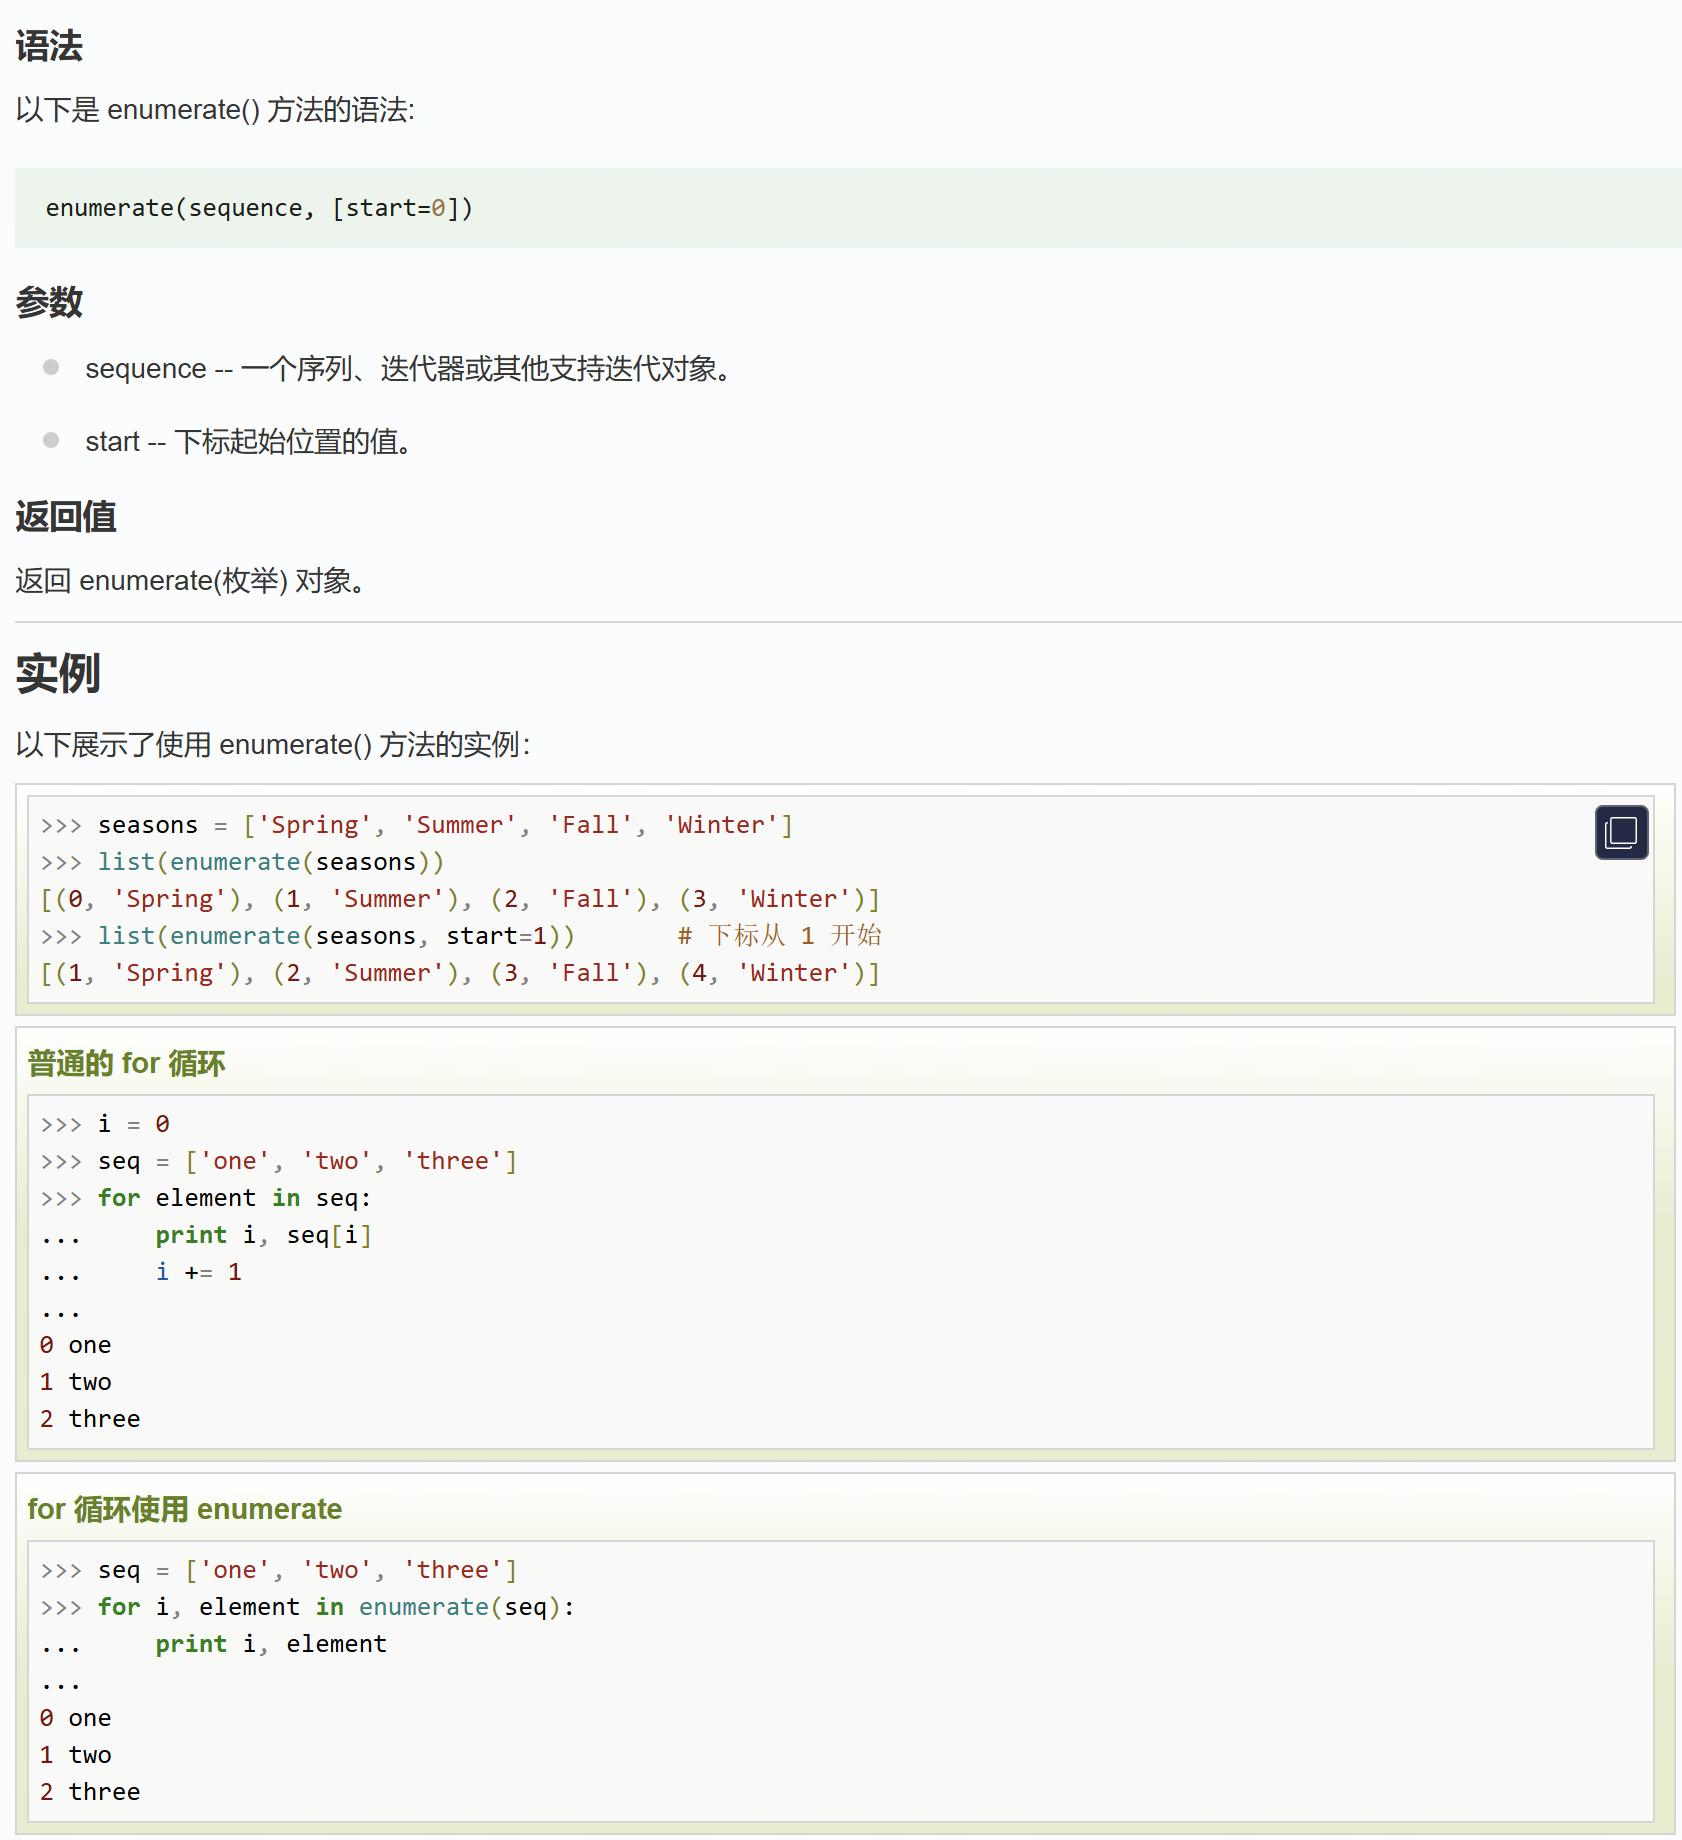

### NumPy 中的**多维切片赋值**操作
这行代码 `T_origin[:3, :3] = joint.rot` 是 NumPy 中非常典型的**多维切片赋值**操作。

#### 基本语法
```python
array[行切片，列切片，深度切片，...]
```
每个维度的切片遵循 `[start : stop : step]` 规则：
*   **start**: 起始索引（包含），默认为 0。
*   **stop**: 结束索引（**不包含**），默认为该维度的长度。
*   **step**: 步长，默认为 1。

#### 常见用法示例

假设我们有一个 2D 数组：
```python
import numpy as np

arr = np.array([
    [0,  1,  2,  3],
    [4,  5,  6,  7],
    [8,  9,  10, 11],
    [12, 13, 14, 15]
])
# 形状为 (4, 4)
```

##### (1) 基础范围切片 `[start:stop]`
```python
# 取前 2 行，所有列
arr[:2, :] 
# 结果：[[0, 1, 2, 3], [4, 5, 6, 7]]

# 取第 1 行到第 3 行（不含第 3 行），第 1 列到第 3 列
arr[1:3, 1:3]
# 结果：[[5, 6], [9, 10]]  (注意：stop 是不包含的)
```

##### (2) 省略写法 `:`
冒号 `:` 单独使用代表“该维度全部”。
```python
arr[:, 0]    # 取所有行的第 0 列 -> [0, 4, 8, 12]
arr[2, :]    # 取第 2 行的所有列 -> [8, 9, 10, 11]
arr[:, :]    # 复制整个数组（浅拷贝）
```

##### (3) 步长切片 `[::step]`
```python
arr[::2, ::2] 
# 行每隔 2 个取一个，列每隔 2 个取一个
# 结果：[[0, 2], [8, 10]] (取第 0,2 行 和 第 0,2 列的交叉点)
```

##### (4) 负数索引
负数表示从后往前数。
```python
arr[-1, :]   # 取最后一行 -> [12, 13, 14, 15]
arr[:, -1]   # 取最后一列 -> [3, 7, 11, 15]
arr[:-1, :-1]# 去掉最后一行和最后一列 -> 左上角 3x3
```

---

#### 关键特性：视图（View）vs 拷贝（Copy）

这是 NumPy 切片**最重要**的特性，也是你代码 `T_origin[:3, :3] = ...` 能生效的原因。

*   **切片返回的是视图（View）**：切片操作**不会复制数据**，它只是指向原数组内存的一块区域。
*   **修改切片会修改原数组**。

**示例：**
```python
sub = arr[:2, :2]  # 取左上角 2x2
sub[0, 0] = 999    # 修改切片中的数据

print(arr[0, 0])   # 输出 999！原数组也被修改了
```

**为什么这很重要？**
1.  **效率高**：不需要分配新内存，适合处理大矩阵。
2.  **原地修改**：就像你的代码 `T_origin[:3, :3] = joint.rot`，直接修改了 `T_origin` 内部的内存，而不需要创建一个新的 `T_origin`。

**如果你想要真正的拷贝（不影响原数组）：**
需要使用 `.copy()` 方法：
```python
sub_copy = arr[:2, :2].copy()
sub_copy[0, 0] = 999
print(arr[0, 0])   # 输出 0，原数组不受影响
```

---

#### 高级技巧：布尔索引与花式索引

除了切片，NumPy 还支持更灵活的选取方式。

##### (1) 布尔索引（筛选）
```python
arr = np.array([1, 5, 3, 8, 2])
mask = arr > 3      # 创建布尔数组 [False, True, False, True, False]
result = arr[mask]  # 筛选出大于 3 的元素 -> [5, 8]
```

##### (2) 花式索引（指定具体下标）
```python
arr = np.array([10, 20, 30, 40, 50])
indices = [0, 2, 4]
result = arr[indices] # 取第 0, 2, 4 个元素 -> [10, 30, 50]
```

In [ ]:
def fk(self, qpos: np.ndarray) -> np.ndarray:
    """
    Compute forward kinematics for all of the links.

    Here we assume the i-th joint has i-th link as parent
    and i+1-th link as child.

    In practice multiple joints can have a shared parent link.
    But dealing with those special cases is not required in the homework.

    The result is in robot frame, which means that the first link
    has (0, 0, 0) as translation and I as rotation matrix

    Here we assume each link's frame, except the first one,
    is as same as its parent joint's frame.

    See https://wiki.ros.org/urdf/XML/joint and urdf_types.py 
    for the definition of Link and Joint.

    You can import functions from rotation.py

    Parameters
    ----------
    qpos: np.ndarray
        The current joint angles with shape (J,)
        (which means its length is the number of revolute joints)

    Returns
    -------
    np.ndarray
        The poses of links with shape (L, 4, 4)
        (which means its length is the number of links)

    Note
    ----
    The 4*4 pose matrix combines translation and rotation.

    Its format is:
        R  t
        0  1
    where R is rotation matrix and t is translation vector
    """
    # 获取机器人一共有多少个Links
    num_links = len(self.links)
    
    # 初始化一个用来存放所有连杆姿态的数组
    poses = np.zeros((num_links, 4, 4))
    
    # 1. 基座（第 0 个 Link）的姿态是单位矩阵
    poses[0] = np.eye(4)
    
    # 准备一个计数器，用来记录当前用到 qpos 里的第几个角度了
    q_idx = 0
    
    # 2. 按照顺序，依次计算每一个关节和它连接的下一个连杆
    for i, joint in enumerate(self.joints):
        # i-th 关节连接的是第 i 个连杆（父）和第 i+1 个连杆（子）
        parent_pose = poses[i]
        
        # --- 第一步：提取关节的初始固定安装变换 (T_origin) ---
        # 这代表了关节相对于父连杆，安装在什么位置、朝向哪里
        T_origin = np.eye(4)
        T_origin[:3, :3] = joint.rot    # 填入 3x3 的旋转矩阵
        T_origin[:3, 3] = joint.trans   # 填入 3 维的平移向量
        
        # --- 第二步：计算电机的动态运动变换 (T_motion) ---
        T_motion = np.eye(4)
        
        # 我们需要判断这个关节是不是会转动的电机（RevoluteJoint）
        # 因为有些关节是死死固定住的（FixedJoint）
        if isinstance(joint, RevoluteJoint):
            # 获取当前这个电机的转动角度
            theta = qpos[q_idx]
            q_idx += 1  # 计数器加1，下一个电机用下一个角度
            
            # 计算轴角 (Axis-Angle)：旋转轴向量 * 旋转角度
            axis_angle = joint.axis * theta
            
            # 把轴角转成 3x3 旋转矩阵
            R_motion = axis_angle_to_mat(axis_angle)
            
            # 把旋转矩阵填入 T_motion
            T_motion[:3, :3] = R_motion
            
        # --- 第三步：核心矩阵相乘，计算子连杆的最终姿态 ---
        # 子连杆姿态 = 父连杆姿态 @ 关节初始安装姿态 @ 关节运动姿态
        child_pose = parent_pose @ T_origin @ T_motion
        
        # 把算出来的姿态存入数组，给第 i+1 个连杆使用
        poses[i + 1] = child_pose
        
    return poses